In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import rasterio
import re
import tifffile
from keras.models import load_model
from keras.preprocessing.image import img_to_array



In [2]:
pip show rasterio


Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install rasterio==1.3.8


     ---------------------------------------- 22.9/22.9 MB 3.7 MB/s eta 0:00:00


In [9]:
import tensorflow as tf
import keras
print(tf.__version__)  # Must be 2.10+ for compatibility
print(keras.__version__)

ImportError: Traceback (most recent call last):
  File "D:\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 62, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: Module use of python310.dll conflicts with this version of Python.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [7]:
!pip uninstall tensorflow keras -y


Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: keras 2.13.1
Uninstalling keras-2.13.1:
  Successfully uninstalled keras-2.13.1


You can safely remove it manually.


In [9]:
!pip uninstall keras -y


In [15]:
!pip install tensorflow==2.13.0 --index-url https://pypi.org/simple


ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0)
ERROR: No matching distribution found for tensorflow==2.13.0


In [5]:
!python --version


Python 3.12.7


In [1]:
!pip install  keras==2.13.1

  Using cached keras-2.13.1-py3-none-any.whl.metadata (2.4 kB)
Using cached keras-2.13.1-py3-none-any.whl (1.7 MB)


In [3]:
!pip install tensorflow==2.13.0 


   ---------------------------------------- 0.0/276.5 MB ? eta -:--:--
   ---------------------------------------- 1.6/276.5 MB 9.3 MB/s eta 0:00:30
    --------------------------------------- 3.7/276.5 MB 9.9 MB/s eta 0:00:28
    --------------------------------------- 6.0/276.5 MB 10.3 MB/s eta 0:00:27
   - -------------------------------------- 8.1/276.5 MB 10.3 MB/s eta 0:00:27
   - -------------------------------------- 9.2/276.5 MB 9.2 MB/s eta 0:00:30
   - -------------------------------------- 11.0/276.5 MB 9.2 MB/s eta 0:00:29
   - -------------------------------------- 12.8/276.5 MB 8.9 MB/s eta 0:00:30
   -- ------------------------------------- 14.7/276.5 MB 9.0 MB/s eta 0:00:29
   -- ------------------------------------- 16.8/276.5 MB 9.2 MB/s eta 0:00:29
   -- ------------------------------------- 18.9/276.5 MB 9.3 MB/s eta 0:00:28
   --- ------------------------------------ 21.0/276.5 MB 9.3 MB/s eta 0:00:28
   --- ------------------------------------ 23.1/276.5 MB 9.4 M

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sqlalchemy 2.0.37 requires typing-extensions>=4.6.0, but you have typing-extensions 4.5.0 which is incompatible.
aext-project-filebrowser-server 4.1.0 requires watchdog==4.0.1, but you have watchdog 4.0.2 which is incompatible.
altair 5.5.0 requires typing-extensions>=4.10.0; python_version < "3.14", but you have typing-extensions 4.5.0 which is incompatible.
glueviz 1.0.0 requires glue-vispy-viewers>=1.0.0, but you have glue-vispy-viewers 0.12.2 which is incompatible.
ipython 8.30.0 requires typing-extensions>=4.6; python_version < "3.12", but you have typing-extensions 4.5.0 which is incompatible.
mypy 1.14.1 requires typing-extensions>=4.6.0, but you have typing-extensions 4.5.0 which is incompatible.
pyopenssl 25.0.0 requires typing-extensions>=4.9; python_version < "3.13" and python_version >= "3.8", but you 

In [79]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Lambda
import rasterio

# Define the custom function for the Lambda layer
def resize_layer(x):
    return tf.image.resize(x, (256, 256), method='bilinear')

# Load the model with the custom function
model = load_model('forest_detection_model_vgg16_unet_311223.h5', 
                   custom_objects={'resize_layer': resize_layer, 'tf': tf})

# Now you can use the model for predictions


In [21]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_percentage(image_paths, tile_size=size):
    num_years = len(image_paths)

    deforestation_percentages = []
    forest_percentages = []

    for i in range(num_years - 1):
        j = i + 1

        # Preprocess the images and split into tiles
        images_i = [preprocess_image(image_path, tile_size) for image_path in image_paths[i:i+2]]

        # Flatten the list of tiles
        tiles_i = [tile for tiles_per_image in images_i for tile in tiles_per_image]

        # Predict using the trained model for all tiles
        predictions_i = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles_i]

        # Calculate the percentage of deforestation for each tile
        deforestation_percentages_i = []
        for k in range(0, len(predictions_i), 2):
            # Calculate the sum of predictions for each pair of tiles
            sum_predictions_i = np.sum(predictions_i[k], axis=-1)
            sum_predictions_j = np.sum(predictions_i[k + 1], axis=-1)

            # Calculate the percentage of deforestation
            non_zero_mask = (sum_predictions_i + sum_predictions_j) != 0
            deforestation_percentage = np.zeros_like(sum_predictions_i)
            deforestation_percentage[non_zero_mask] = (
                np.abs(sum_predictions_j[non_zero_mask] - sum_predictions_i[non_zero_mask]) /
                (sum_predictions_i[non_zero_mask] + sum_predictions_j[non_zero_mask])
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate the overall percentage for this pair of years
        deforestation_percentages.append(np.nanmean(deforestation_percentages_i))

        # Calculate the percentage of remaining forest
        forest_percentage_i = 100 - np.nanmean(deforestation_percentages_i)
        forest_percentages.append(forest_percentage_i)

    return deforestation_percentages, forest_percentages

def visualize_deforestation(image_paths):
    num_images = len(image_paths)

    deforestation_percentages, forest_percentages = calculate_deforestation_percentage(image_paths)

    for i, image_path in enumerate(image_paths):
        # Load the original image using rasterio
        with rasterio.open(image_path) as src:
            r = src.read(3, masked=True)
            g = src.read(2, masked=True)
            b = src.read(1, masked=True)

        rStd = scaleStd(r)
        gStd = scaleStd(g)
        bStd = scaleStd(b)

        rgbStd = np.dstack((rStd, gStd, bStd)).copy()  # Make a copy
        # Commenting out the line that displays the image
        # axes[i].imshow(np.asarray(rgbStd, dtype=np.float32))  # Ensure the array is writable
        # axes[i].set_title(f"Original Image - {os.path.basename(image_path)}")

        # Print deforestation and forest percentages for each image
        if i > 0:
            year1 = extract_year_from_filename(os.path.basename(image_paths[i - 1]))
            year2 = extract_year_from_filename(os.path.basename(image_path))
            deforestation_text = f"Non-Forest Percentage - {year1} to {year2}: {deforestation_percentages[i - 1]:.2f}%"
            forest_text = f"Remaining Forest Percentage - {year1} to {year2}: {forest_percentages[i - 1]:.2f}%"
            print(deforestation_text)
            print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None

def preprocess_image(image_path, tile_size=size):
    # Load and preprocess the image
    img = tifffile.imread(image_path)
    img_height, img_width, _ = img.shape

    # Split the image into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = img[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to the maximum width and height
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant') for tile in tiles]

    # Preprocess each tile
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles

# Provide the directory containing satellite images for different years
image_directory = "testimage/tang"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 3s 3s/step


C:\Users\Firoz\AppData\Local\Temp\ipykernel_24776\2053249458.py:47: RuntimeWarning: Mean of empty slice
  deforestation_percentages_i.append(np.nanmean(deforestation_percentage))


1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 3s 3s/step


1/1 [==============================] - 4s 4s/step


...

1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 3s 3s/step


1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 4s 4s/step
Non-Forest Percentage - 2006 to 2007: 3.58%
Remaining Forest Percentage - 2006 to 2007: 96.42%
Non-Forest Percentage - 2007 to 2008: 4.01%
Remaining Forest Percentage - 2007 to 2008: 95.99%
Non-Forest Percentage - 2008 to 2009: 3.60%
Remaining Forest Percentage - 2008 to 2009: 96.40%
Non-Forest Percentage - 2009 to 2010: 2.95%
Remaining Forest Percentage - 2009 to 2010: 97.05%
Non-Forest Percentage - 2010 to 2011: 3.00%
Remaining Forest Percentage - 2010 to 2011: 97.00%
Non-Forest Percentage - 2011 to 2012: 2.84%
Remaining Forest Percentage - 2011 to 2012: 97.16%
Non-Forest Percentage - 2012 to 2013: 2.73%
Remaining Forest Percentage - 2012 to 2013: 97.27%
Non-Forest Percentage - 2013 to 2014: 3.07%
Remaining Forest Percentage - 2013 to 2014: 96.93%
Non-Forest Percentage - 2014 to 2015: 3.45%
Remaining Forest Percentage - 2014 to 2015: 96.55%
Non-Forest Percentage - 2015 to 2016: 3.85%
Remaining Forest Percentage - 2015 to 2016: 96.15%


In [24]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_percentage(image_paths, tile_size=size):
    num_years = len(image_paths)

    deforestation_percentages = []
    forest_percentages = []

    for i in range(num_years - 1):
        j = i + 1

        # Preprocess the images and split into tiles
        images_i = [preprocess_image(image_path, tile_size) for image_path in image_paths[i:i+2]]

        # Flatten the list of tiles
        tiles_i = [tile for tiles_per_image in images_i for tile in tiles_per_image]

        # Predict using the trained model for all tiles
        predictions_i = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles_i]

        # Calculate the percentage of deforestation for each tile
        deforestation_percentages_i = []
        for k in range(0, len(predictions_i), 2):
            # Calculate the sum of predictions for each pair of tiles
            sum_predictions_i = np.sum(predictions_i[k], axis=-1)
            sum_predictions_j = np.sum(predictions_i[k + 1], axis=-1)

            # Calculate the percentage of deforestation
            non_zero_mask = (sum_predictions_i + sum_predictions_j) != 0
            deforestation_percentage = np.zeros_like(sum_predictions_i)
            deforestation_percentage[non_zero_mask] = (
                np.abs(sum_predictions_j[non_zero_mask] - sum_predictions_i[non_zero_mask]) /
                (sum_predictions_i[non_zero_mask] + sum_predictions_j[non_zero_mask])
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate the overall percentage for this pair of years
        deforestation_percentages.append(np.nanmean(deforestation_percentages_i))

        # Calculate the percentage of remaining forest
        forest_percentage_i = 100 - np.nanmean(deforestation_percentages_i)
        forest_percentages.append(forest_percentage_i)

    return deforestation_percentages, forest_percentages

def visualize_deforestation(image_paths):
    num_images = len(image_paths)

    deforestation_percentages, forest_percentages = calculate_deforestation_percentage(image_paths)

    for i, image_path in enumerate(image_paths):
        # Load the original image using rasterio
        with rasterio.open(image_path) as src:
            r = src.read(3, masked=True)
            g = src.read(2, masked=True)
            b = src.read(1, masked=True)

        rStd = scaleStd(r)
        gStd = scaleStd(g)
        bStd = scaleStd(b)

        rgbStd = np.dstack((rStd, gStd, bStd)).copy()  # Make a copy
        # Commenting out the line that displays the image
        # axes[i].imshow(np.asarray(rgbStd, dtype=np.float32))  # Ensure the array is writable
        # axes[i].set_title(f"Original Image - {os.path.basename(image_path)}")

        # Print deforestation and forest percentages for each image
        if i > 0:
            year1 = extract_year_from_filename(os.path.basename(image_paths[i - 1]))
            year2 = extract_year_from_filename(os.path.basename(image_path))
            deforestation_text = f"Non-Forest Percentage - {year1} to {year2}: {deforestation_percentages[i - 1]:.2f}%"
            forest_text = f"Remaining Forest Percentage - {year1} to {year2}: {forest_percentages[i - 1]:.2f}%"
            print(deforestation_text)
            print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None

def preprocess_image(image_path, tile_size=size):
    # Load and preprocess the image
    img = tifffile.imread(image_path)
    img_height, img_width, _ = img.shape

    # Split the image into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = img[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to the maximum width and height
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant') for tile in tiles]

    # Preprocess each tile
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles

# Provide the directory containing satellite images for different years
image_directory = "testimage/tang/future"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 4s 4s/step


C:\Users\Firoz\AppData\Local\Temp\ipykernel_24776\1705505621.py:47: RuntimeWarning: Mean of empty slice
  deforestation_percentages_i.append(np.nanmean(deforestation_percentage))


1/1 [==============================] - 4s 4s/step
Non-Forest Percentage - 2024 to 2025: 19.97%
Remaining Forest Percentage - 2024 to 2025: 80.03%
Non-Forest Percentage - 2025 to 2026: 20.57%
Remaining Forest Percentage - 2025 to 2026: 79.43%


In [18]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_percentage(image_paths, tile_size=size):
    num_years = len(image_paths)

    deforestation_percentages = []
    forest_percentages = []

    for i in range(num_years - 1):
        j = i + 1

        # Preprocess the images and split into tiles
        images_i = [preprocess_image(image_path, tile_size) for image_path in image_paths[i:i+2]]

        # Flatten the list of tiles
        tiles_i = [tile for tiles_per_image in images_i for tile in tiles_per_image]

        # Predict using the trained model for all tiles
        predictions_i = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles_i]

        # Calculate the percentage of deforestation for each tile
        deforestation_percentages_i = []
        for k in range(0, len(predictions_i), 2):
            # Calculate the sum of predictions for each pair of tiles
            sum_predictions_i = np.sum(predictions_i[k], axis=-1)
            sum_predictions_j = np.sum(predictions_i[k + 1], axis=-1)

            # Calculate the percentage of deforestation
            non_zero_mask = (sum_predictions_i + sum_predictions_j) != 0
            deforestation_percentage = np.zeros_like(sum_predictions_i)
            deforestation_percentage[non_zero_mask] = (
                np.abs(sum_predictions_j[non_zero_mask] - sum_predictions_i[non_zero_mask]) /
                (sum_predictions_i[non_zero_mask] + sum_predictions_j[non_zero_mask])
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate the overall percentage for this pair of years
        deforestation_percentages.append(np.nanmean(deforestation_percentages_i))

        # Calculate the percentage of remaining forest
        forest_percentage_i = 100 - np.nanmean(deforestation_percentages_i)
        forest_percentages.append(forest_percentage_i)

    return deforestation_percentages, forest_percentages

def visualize_deforestation(image_paths):
    num_images = len(image_paths)

    deforestation_percentages, forest_percentages = calculate_deforestation_percentage(image_paths)

    for i, image_path in enumerate(image_paths):
        # Load the original image using rasterio
        with rasterio.open(image_path) as src:
            r = src.read(3, masked=True)
            g = src.read(2, masked=True)
            b = src.read(1, masked=True)

        rStd = scaleStd(r)
        gStd = scaleStd(g)
        bStd = scaleStd(b)

        rgbStd = np.dstack((rStd, gStd, bStd)).copy()  # Make a copy
        # Commenting out the line that displays the image
        # axes[i].imshow(np.asarray(rgbStd, dtype=np.float32))  # Ensure the array is writable
        # axes[i].set_title(f"Original Image - {os.path.basename(image_path)}")

        # Print deforestation and forest percentages for each image
        if i > 0:
            year1 = extract_year_from_filename(os.path.basename(image_paths[i - 1]))
            year2 = extract_year_from_filename(os.path.basename(image_path))
            deforestation_text = f"Non-Forest Percentage - {year1} to {year2}: {deforestation_percentages[i - 1]:.2f}%"
            forest_text = f"Remaining Forest Percentage - {year1} to {year2}: {forest_percentages[i - 1]:.2f}%"
            print(deforestation_text)
            print(forest_text)

def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None

def preprocess_image(image_path, tile_size=size):
    # Load and preprocess the image
    img = tifffile.imread(image_path)
    img_height, img_width, _ = img.shape

    # Split the image into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = img[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to the maximum width and height
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant') for tile in tiles]

    # Preprocess each tile
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles

# Provide the directory containing satellite images for different years
image_directory = "testimage/tang/future"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 2s 2s/step


C:\Users\Firoz\AppData\Local\Temp\ipykernel_24776\4291146665.py:47: RuntimeWarning: Mean of empty slice
  deforestation_percentages_i.append(np.nanmean(deforestation_percentage))


1/1 [==============================] - 2s 2s/step
Non-Forest Percentage - 2024 to 2025: 19.97%
Remaining Forest Percentage - 2024 to 2025: 80.03%
Non-Forest Percentage - 2025 to 2026: 20.57%
Remaining Forest Percentage - 2025 to 2026: 79.43%


In [16]:
image_directory = "testimage/tang/future"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]
num_years = len(image_paths)
print(num_years)

3


In [26]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_per_year(image_paths, tile_size=size):
    num_years = len(image_paths)
    
    deforestation_percentages = []
    forest_percentages = []
    
    for i in range(num_years):
        # Preprocess the image and split into tiles
        tiles = preprocess_image(image_paths[i], tile_size)

        # Predict using the trained model for all tiles
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        # Calculate the percentage of non-forest for each tile
        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            
            # Calculate the percentage of non-forest (deforestation)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate overall deforestation and forest percentage for the year
        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages


def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))

        deforestation_text = f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%"
        forest_text = f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%"
        
        print(deforestation_text)
        print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None

def preprocess_image(image_path, tile_size=size):
    # Load and preprocess the image
    img = tifffile.imread(image_path)
    img_height, img_width, _ = img.shape

    # Split the image into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = img[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to the maximum width and height
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant') for tile in tiles]

    # Preprocess each tile
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles

# Provide the directory containing satellite images for different years
image_directory = "testimage/tang"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 4s 4s/step


C:\Users\Firoz\AppData\Local\Temp\ipykernel_24776\1801026862.py:39: RuntimeWarning: Mean of empty slice
  deforestation_percentages_i.append(np.nanmean(deforestation_percentage))


1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 5s 5s/step


1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 5s 5s/step
Non-Forest Percentage - 2006: 88.34%
Remaining Forest Percentage - 2006: 11.66%
Non-Forest Percentage - 2007: 87.92%
Remaining Forest Percentage - 2007: 12.08%
Non-Forest Percentage - 2008: 88.93%
Remaining Forest Percentage - 2008: 11.07%
Non-Forest Percentage - 2009: 88.84%
Remaining Forest Percentage - 2009: 11.16%
Non-Forest Percentage - 2010: 92.26%
Remaining Forest Percentage - 2010: 7.74%
Non-Forest Percentage - 2011: 90.21%
Remaining Forest Percentage - 2011: 9.79%
Non-Forest Percentage - 2012: 93.22%
Remaining Forest Percentage - 2012: 6.78%
Non-Forest Percentage - 2013: 90.14%
Remaining Forest Percentage - 2013: 9.86%
Non-Forest Percentage - 2014: 92.30%
Remaining Forest Percentage - 2014: 7.70%
Non-Forest Percentage - 2015: 87.04%
Remaining Forest Percentage - 2015: 12.96%
Non-Forest Percentage - 2016: 87.69%
Remaining Forest Percentage - 2016: 12.31%
Non-Forest Percentage - 2017: 92.75%
Remaining Forest Percentage - 2017: 7.

In [6]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_per_year(image_paths, tile_size=size):
    num_years = len(image_paths)
    
    deforestation_percentages = []
    forest_percentages = []
    
    for i in range(num_years):
        # Preprocess the image and split into tiles
        tiles = preprocess_image(image_paths[i], tile_size)

        # Predict using the trained model for all tiles
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        # Calculate the percentage of non-forest for each tile
        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            
            # Calculate the percentage of non-forest (deforestation)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate overall deforestation and forest percentage for the year
        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages


def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))

        deforestation_text = f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%"
        forest_text = f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%"
        
        print(deforestation_text)
        print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None
    
def preprocess_image(image_path, tile_size=size):
    # Load the image using rasterio for specific band access
    with rasterio.open(image_path) as src:
        red = src.read(1, masked=True)
        green = src.read(2, masked=True)
        blue = src.read(3, masked=True)

    # Normalize bands
    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    # Stack normalized bands into RGB image
    rgb_std = np.dstack((r_std, g_std, b_std))

    # Convert to float32 and scale to 0–255
    rgb_std = np.clip(rgb_std, 0, 1)  # Make sure values are within range
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    # Split into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to match maximum height/width
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]

    # Preprocess for model input
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles


# Provide the directory containing satellite images for different years
image_directory = "testimage/tang"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 0s 152ms/step


1/1 [==============================] - 0s 177ms/step


1/1 [==============================] - 0s 170ms/step


1/1 [==============================] - 0s 179ms/step


1/1 [==============================] - 0s 193ms/step


1/1 [==============================] - 0s 167ms/step


1/1 [==============================] - 0s 191ms/step
Non-Forest Percentage - 2006: 78.89%
Remaining Forest Percentage - 2006: 21.11%
Non-Forest Percentage - 2007: 78.66%
Remaining Forest Percentage - 2007: 21.34%
Non-Forest Percentage - 2008: 78.58%
Remaining Forest Percentage - 2008: 21.42%
Non-Forest Percentage - 2009: 77.87%
Remaining Forest Percentage - 2009: 22.13%
Non-Forest Percentage - 2010: 78.55%
Remaining Forest Percentage - 2010: 21.45%
Non-Forest Percentage - 2011: 78.54%
Remaining Forest Percentage - 2011: 21.46%
Non-Forest Percentage - 2012: 77.62%
Remaining Forest Percentage - 2012: 22.38%
Non-Forest Percentage - 2013: 78.32%
Remaining Forest Percentage - 2013: 21.68%
Non-Forest Percentage - 2014: 78.89%
Remaining Forest Percentage - 2014: 21.11%
Non-Forest Percentage - 2015: 79.74%
Remaining Forest Percentage - 2015: 20.26%
Non-Forest Percentage - 2016: 77.65%
Remaining Forest Percentage - 2016: 22.35%
Non-Forest Percentage - 2017: 79.19%
Remaining Forest Percentage - 

In [25]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_per_year(image_paths, tile_size=size):
    num_years = len(image_paths)
    
    deforestation_percentages = []
    forest_percentages = []
    
    for i in range(num_years):
        # Preprocess the image and split into tiles
        tiles = preprocess_image(image_paths[i], tile_size)

        # Predict using the trained model for all tiles
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        # Calculate the percentage of non-forest for each tile
        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            
            # Calculate the percentage of non-forest (deforestation)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate overall deforestation and forest percentage for the year
        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages


def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))

        deforestation_text = f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%"
        forest_text = f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%"
        
        print(deforestation_text)
        print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None

def preprocess_image(image_path, tile_size=size):
    # Load and preprocess the image
    img = tifffile.imread(image_path)
    img_height, img_width, _ = img.shape

    # Split the image into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = img[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to the maximum width and height
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant') for tile in tiles]

    # Preprocess each tile
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles

# Provide the directory containing satellite images for different years
image_directory = "testimage/tang/future"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 4s 4s/step


C:\Users\Firoz\AppData\Local\Temp\ipykernel_24776\3600546541.py:39: RuntimeWarning: Mean of empty slice
  deforestation_percentages_i.append(np.nanmean(deforestation_percentage))


1/1 [==============================] - 4s 4s/step
Non-Forest Percentage - 2024: 16.73%
Remaining Forest Percentage - 2024: 83.27%
Non-Forest Percentage - 2025: 17.15%
Remaining Forest Percentage - 2025: 82.85%
Non-Forest Percentage - 2026: 17.15%
Remaining Forest Percentage - 2026: 82.85%


In [3]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_per_year(image_paths, tile_size=size):
    num_years = len(image_paths)
    
    deforestation_percentages = []
    forest_percentages = []
    
    for i in range(num_years):
        # Preprocess the image and split into tiles
        tiles = preprocess_image(image_paths[i], tile_size)

        # Predict using the trained model for all tiles
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        # Calculate the percentage of non-forest for each tile
        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            
            # Calculate the percentage of non-forest (deforestation)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate overall deforestation and forest percentage for the year
        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages


def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))

        deforestation_text = f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%"
        forest_text = f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%"
        
        print(deforestation_text)
        print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None
    
def preprocess_image(image_path, tile_size=size):
    # Load the image using rasterio for specific band access
    with rasterio.open(image_path) as src:
        red = src.read(1, masked=True)
        green = src.read(2, masked=True)
        blue = src.read(3, masked=True)

    # Normalize bands
    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    # Stack normalized bands into RGB image
    rgb_std = np.dstack((r_std, g_std, b_std))

    # Convert to float32 and scale to 0–255
    rgb_std = np.clip(rgb_std, 0, 1)  # Make sure values are within range
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    # Split into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to match maximum height/width
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]

    # Preprocess for model input
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles


# Provide the directory containing satellite images for different years
image_directory = "testimage/tang/norm"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 0s 256ms/step


1/1 [==============================] - 0s 261ms/step


1/1 [==============================] - 0s 273ms/step


1/1 [==============================] - 0s 347ms/step


1/1 [==============================] - 0s 308ms/step


1/1 [==============================] - 0s 329ms/step


1/1 [==============================] - 0s 336ms/step


1/1 [==============================] - 0s 364ms/step


1/1 [==============================] - 0s 306ms/step


1/1 [==============================] - 0s 316ms/step
Non-Forest Percentage - 2013: 79.93%
Remaining Forest Percentage - 2013: 20.07%
Non-Forest Percentage - 2014: 81.22%
Remaining Forest Percentage - 2014: 18.78%
Non-Forest Percentage - 2015: 81.83%
Remaining Forest Percentage - 2015: 18.17%
Non-Forest Percentage - 2016: 80.89%
Remaining Forest Percentage - 2016: 19.11%
Non-Forest Percentage - 2017: 81.29%
Remaining Forest Percentage - 2017: 18.71%
Non-Forest Percentage - 2018: 80.75%
Remaining Forest Percentage - 2018: 19.25%
Non-Forest Percentage - 2019: 81.31%
Remaining Forest Percentage - 2019: 18.69%
Non-Forest Percentage - 2020: 81.04%
Remaining Forest Percentage - 2020: 18.96%
Non-Forest Percentage - 2021: 81.19%
Remaining Forest Percentage - 2021: 18.81%
Non-Forest Percentage - 2022: 81.13%
Remaining Forest Percentage - 2022: 18.87%
Non-Forest Percentage - 2023: 81.09%
Remaining Forest Percentage - 2023: 18.91%
Non-Forest Percentage - 2024: 81.08%
Remaining Forest Percentage - 

In [7]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_per_year(image_paths, tile_size=size):
    num_years = len(image_paths)
    
    deforestation_percentages = []
    forest_percentages = []
    
    for i in range(num_years):
        # Preprocess the image and split into tiles
        tiles = preprocess_image(image_paths[i], tile_size)

        # Predict using the trained model for all tiles
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        # Calculate the percentage of non-forest for each tile
        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            
            # Calculate the percentage of non-forest (deforestation)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate overall deforestation and forest percentage for the year
        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages


def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))

        deforestation_text = f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%"
        forest_text = f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%"
        
        print(deforestation_text)
        print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None
    
def preprocess_image(image_path, tile_size=size):
    # Load the image using rasterio for specific band access
    with rasterio.open(image_path) as src:
        red = src.read(1, masked=True)
        green = src.read(2, masked=True)
        blue = src.read(3, masked=True)

    # Normalize bands
    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    # Stack normalized bands into RGB image
    rgb_std = np.dstack((r_std, g_std, b_std))

    # Convert to float32 and scale to 0–255
    rgb_std = np.clip(rgb_std, 0, 1)  # Make sure values are within range
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    # Split into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to match maximum height/width
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]

    # Preprocess for model input
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles


# Provide the directory containing satellite images for different years
image_directory = "testimage/tang"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 0s 184ms/step


1/1 [==============================] - 0s 206ms/step


1/1 [==============================] - 0s 190ms/step


1/1 [==============================] - 0s 189ms/step


1/1 [==============================] - 0s 194ms/step


1/1 [==============================] - 0s 185ms/step


1/1 [==============================] - 0s 195ms/step
Non-Forest Percentage - 2006: 78.89%
Remaining Forest Percentage - 2006: 21.11%
Non-Forest Percentage - 2007: 78.66%
Remaining Forest Percentage - 2007: 21.34%
Non-Forest Percentage - 2008: 78.58%
Remaining Forest Percentage - 2008: 21.42%
Non-Forest Percentage - 2009: 77.87%
Remaining Forest Percentage - 2009: 22.13%
Non-Forest Percentage - 2010: 78.55%
Remaining Forest Percentage - 2010: 21.45%
Non-Forest Percentage - 2011: 78.54%
Remaining Forest Percentage - 2011: 21.46%
Non-Forest Percentage - 2012: 77.62%
Remaining Forest Percentage - 2012: 22.38%
Non-Forest Percentage - 2013: 78.32%
Remaining Forest Percentage - 2013: 21.68%
Non-Forest Percentage - 2014: 78.89%
Remaining Forest Percentage - 2014: 21.11%
Non-Forest Percentage - 2015: 79.74%
Remaining Forest Percentage - 2015: 20.26%
Non-Forest Percentage - 2016: 77.65%
Remaining Forest Percentage - 2016: 22.35%
Non-Forest Percentage - 2017: 79.19%
Remaining Forest Percentage - 

In [5]:
import tensorflow as tf
size = 256
# Load the pre-trained U-Net model
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / ((np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    # Assuming pixel values are in the range [0, 255]
    image = image / 255.0
    return image

def calculate_deforestation_per_year(image_paths, tile_size=size):
    num_years = len(image_paths)
    
    deforestation_percentages = []
    forest_percentages = []
    
    for i in range(num_years):
        # Preprocess the image and split into tiles
        tiles = preprocess_image(image_paths[i], tile_size)

        # Predict using the trained model for all tiles
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        # Calculate the percentage of non-forest for each tile
        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            
            # Calculate the percentage of non-forest (deforestation)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()
            ) * 100

            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        # Calculate overall deforestation and forest percentage for the year
        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages


def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))

        deforestation_text = f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%"
        forest_text = f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%"
        
        print(deforestation_text)
        print(forest_text)


def extract_year_from_filename(filename):
    # Extract the last 4 digits from the filename
    match = re.search(r'\d{4}', filename)
    if match:
        return int(match.group())
    else:
        return None
    
def preprocess_image(image_path, tile_size=size):
    # Load the image using rasterio for specific band access
    with rasterio.open(image_path) as src:
        red = src.read(1, masked=True)
        green = src.read(2, masked=True)
        blue = src.read(3, masked=True)

    # Normalize bands
    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    # Stack normalized bands into RGB image
    rgb_std = np.dstack((r_std, g_std, b_std))

    # Convert to float32 and scale to 0–255
    rgb_std = np.clip(rgb_std, 0, 1)  # Make sure values are within range
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    # Split into tiles
    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y+tile_size, x:x+tile_size, :]
            tiles.append(tile)

    # Pad tiles with zeros to match maximum height/width
    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]

    # Preprocess for model input
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles


# Provide the directory containing satellite images for different years
image_directory = "testimage/tang/future/norm"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]

# Visualize deforestation on the original images without showing the map
visualize_deforestation(image_paths)

1/1 [==============================] - 0s 209ms/step


1/1 [==============================] - 0s 194ms/step
Non-Forest Percentage - 2021: 81.22%
Remaining Forest Percentage - 2021: 18.78%
Non-Forest Percentage - 2022: 81.05%
Remaining Forest Percentage - 2022: 18.95%
Non-Forest Percentage - 2023: 81.08%
Remaining Forest Percentage - 2023: 18.92%
Non-Forest Percentage - 2024: 81.18%
Remaining Forest Percentage - 2024: 18.82%
Non-Forest Percentage - 2025: 81.52%
Remaining Forest Percentage - 2025: 18.48%


In [6]:
import os
import re
import numpy as np
import rasterio
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
import scipy.ndimage as ndimage

size = 256
model = load_model('forest_detection_model_vgg16_unet_311223.h5')

def scaleStd(x):
    return (x - (np.nanmean(x) - np.nanstd(x) * 2)) / (
        (np.nanmean(x) + np.nanstd(x) * 2) - (np.nanmean(x) - np.nanstd(x) * 2))

def preprocess_input(image):
    image = image / 255.0
    return image

def fill_gaps_with_interpolation(band):
    if np.ma.isMaskedArray(band):
        band = band.filled(np.nan)
    mask = np.isnan(band)
    filled_band = ndimage.generic_filter(band, np.nanmean, size=3)
    band[mask] = filled_band[mask]
    return band

def calculate_deforestation_per_year(image_paths, tile_size=size):
    deforestation_percentages = []
    forest_percentages = []

    for image_path in image_paths:
        tiles = preprocess_image(image_path, tile_size)
        predictions = [model.predict(np.expand_dims(tile, axis=0)) for tile in tiles]

        deforestation_percentages_i = []
        for prediction in predictions:
            sum_prediction = np.sum(prediction, axis=-1)
            non_zero_mask = sum_prediction != 0
            deforestation_percentage = np.zeros_like(sum_prediction)
            deforestation_percentage[non_zero_mask] = (
                sum_prediction[non_zero_mask] / sum_prediction[non_zero_mask].max()) * 100
            deforestation_percentages_i.append(np.nanmean(deforestation_percentage))

        avg_deforestation = np.nanmean(deforestation_percentages_i)
        deforestation_percentages.append(avg_deforestation)
        forest_percentages.append(100 - avg_deforestation)

    return deforestation_percentages, forest_percentages

def visualize_deforestation(image_paths):
    deforestation_percentages, forest_percentages = calculate_deforestation_per_year(image_paths)

    for i, image_path in enumerate(image_paths):
        year = extract_year_from_filename(os.path.basename(image_path))
        print(f"Non-Forest Percentage - {year}: {deforestation_percentages[i]:.2f}%")
        print(f"Remaining Forest Percentage - {year}: {forest_percentages[i]:.2f}%")

def extract_year_from_filename(filename):
    match = re.search(r'\d{4}', filename)
    return int(match.group()) if match else None

def preprocess_image(image_path, tile_size=size):
    with rasterio.open(image_path) as src:
        red = fill_gaps_with_interpolation(src.read(1, masked=True))
        green = fill_gaps_with_interpolation(src.read(2, masked=True))
        blue = fill_gaps_with_interpolation(src.read(3, masked=True))

    r_std = scaleStd(red)
    g_std = scaleStd(green)
    b_std = scaleStd(blue)

    rgb_std = np.dstack((r_std, g_std, b_std))
    rgb_std = np.clip(rgb_std, 0, 1)
    rgb_std = (rgb_std * 255).astype(np.uint8)

    img_height, img_width, _ = rgb_std.shape

    tiles = []
    for y in range(0, img_height, tile_size):
        for x in range(0, img_width, tile_size):
            tile = rgb_std[y:y + tile_size, x:x + tile_size, :]
            tiles.append(tile)

    max_width = max(tile.shape[1] for tile in tiles)
    max_height = max(tile.shape[0] for tile in tiles)
    padded_tiles = [
        np.pad(tile, ((0, max_height - tile.shape[0]), (0, max_width - tile.shape[1]), (0, 0)), 'constant')
        for tile in tiles
    ]
    preprocessed_tiles = [preprocess_input(img_to_array(tile)) for tile in padded_tiles]

    return preprocessed_tiles

# Directory of normalized Landsat images (one per year)
image_directory = "testimage/tang/interpolation"
image_paths = [os.path.join(image_directory, f) for f in os.listdir(image_directory) if f.endswith(".tif")]

# Run deforestation analysis
visualize_deforestation(image_paths)


C:\Users\Firoz\anaconda3\lib\site-packages\scipy\ndimage\_filters.py:1633: RuntimeWarning: Mean of empty slice
  _nd_image.generic_filter(input, function, footprint, output, mode,


1/1 [==============================] - 0s 187ms/step


1/1 [==============================] - 0s 190ms/step
Non-Forest Percentage - 2006: 78.82%
Remaining Forest Percentage - 2006: 21.18%
Non-Forest Percentage - 2007: 78.58%
Remaining Forest Percentage - 2007: 21.42%
Non-Forest Percentage - 2008: 78.54%
Remaining Forest Percentage - 2008: 21.46%
Non-Forest Percentage - 2009: 77.81%
Remaining Forest Percentage - 2009: 22.19%
Non-Forest Percentage - 2010: 78.50%
Remaining Forest Percentage - 2010: 21.50%


In [8]:
def visualize_rgb_interpolation(image_path):
    with rasterio.open(image_path) as src:
        red = src.read(1, masked=True)
        green = src.read(2, masked=True)
        blue = src.read(3, masked=True)

    # Stack original (with gaps)
    rgb_original = np.dstack((red, green, blue)).astype(np.float32)
    
    # Fill gaps
    red_filled = fill_gaps_with_interpolation(red.copy())
    green_filled = fill_gaps_with_interpolation(green.copy())
    blue_filled = fill_gaps_with_interpolation(blue.copy())
    rgb_filled = np.dstack((red_filled, green_filled, blue_filled)).astype(np.float32)

    # Normalize for visualization
    def normalize(x):
        x = x - np.nanmin(x)
        max_val = np.nanmax(x)
        return (x / max_val) if max_val != 0 else x

    rgb_original_norm = normalize(rgb_original)
    rgb_filled_norm = normalize(rgb_filled)

    # Show original vs interpolated
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(np.clip(rgb_original_norm, 0, 1))
    axes[0].set_title("Original RGB (With Gaps)")
    axes[0].axis("off")

    axes[1].imshow(np.clip(rgb_filled_norm, 0, 1))
    axes[1].set_title("RGB After Interpolation")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


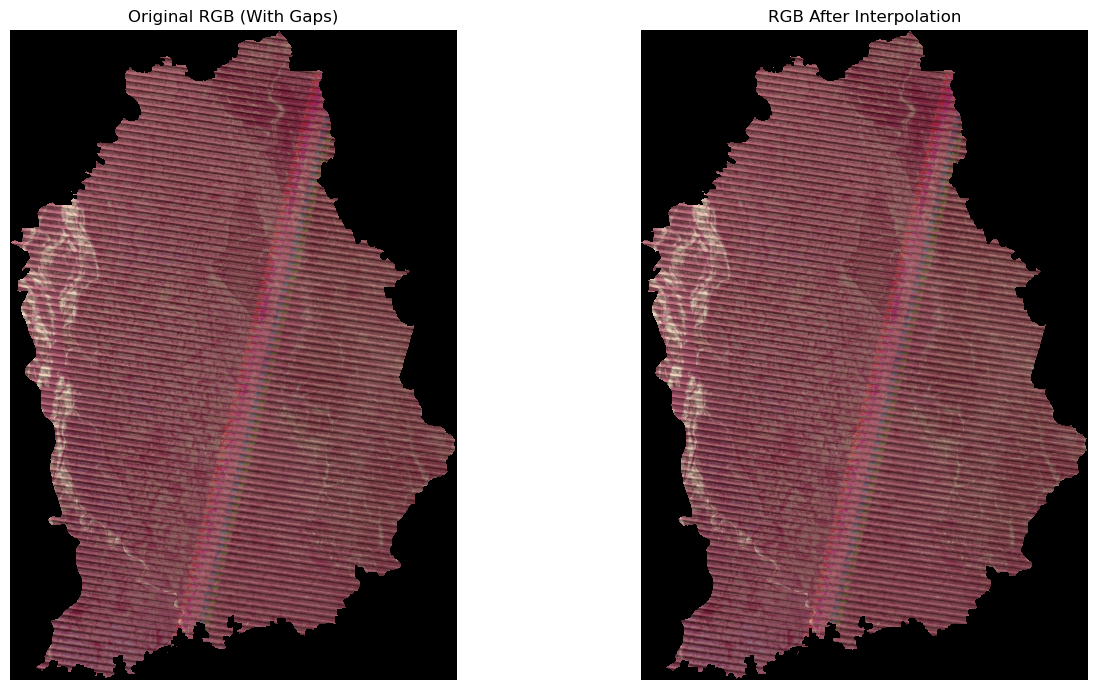

In [10]:
image_path = "testimage/tang/interpolation/modhu_comp_2006.tif"  # Replace with your image path
visualize_rgb_interpolation(image_path)


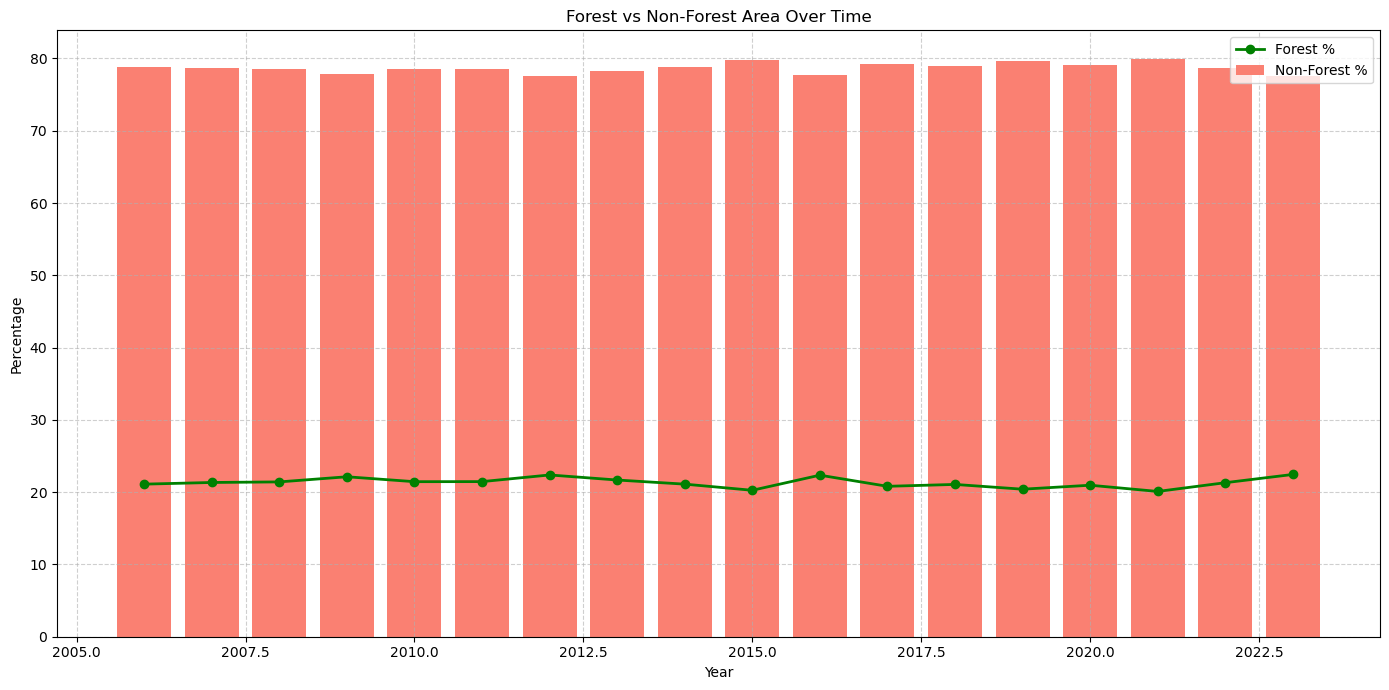

In [8]:
import matplotlib.pyplot as plt

# Years and percentages (manually filled from your output)
years = list(range(2006, 2024))

non_forest_percentages = [
    78.89, 78.66, 78.58, 77.87, 78.55, 78.54, 77.62, 78.32, 78.89,
    79.74, 77.65, 79.19, 78.93, 79.59, 79.04, 79.90, 78.69, 77.55
]

forest_percentages = [
    21.11, 21.34, 21.42, 22.13, 21.45, 21.46, 22.38, 21.68, 21.11,
    20.26, 22.35, 20.81, 21.07, 20.41, 20.96, 20.10, 21.31, 22.45
]

# Set figure size
plt.figure(figsize=(14, 7))

# Bar chart for non-forest
plt.bar(years, non_forest_percentages, color='salmon', label='Non-Forest %')

# Line plot for forest
plt.plot(years, forest_percentages, color='green', marker='o', linewidth=2, label='Forest %')

# Labels and Title
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.title("Forest vs Non-Forest Area Over Time")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()


In [3]:
with rasterio.open("testimage/tang/future/norm/modhu_2024.tif") as src:
    print("Band count:", src.count)
    print("Band shape:", src.read(1).shape)


Band count: 3
Band shape: (3060, 2104)


In [85]:
import tensorflow as tf
import numpy as np
import rasterio
import tifffile
import os
import re
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array

size = 256

# Ensure TensorFlow is passed explicitly
def resize_layer(x):
    return tf.image.resize(x, (256, 256), method='bilinear')

# Load the model with TensorFlow registered in custom objects
model = load_model(
    'forest_detection_model_vgg16_unet_311223.h5',
    custom_objects={'resize_layer': resize_layer, 'tf': tf}
)


In [89]:
image_directory = "testimage/tang"
image_paths = [os.path.join(image_directory, filename) for filename in os.listdir(image_directory) if filename.endswith(".tif")]
print(image_paths)

['testimage/tang\\modhu_comp_2006.tif', 'testimage/tang\\modhu_comp_2007.tif', 'testimage/tang\\modhu_comp_2008.tif', 'testimage/tang\\modhu_comp_2009.tif', 'testimage/tang\\modhu_comp_2010.tif', 'testimage/tang\\modhu_comp_2011.tif', 'testimage/tang\\modhu_comp_2012.tif', 'testimage/tang\\modhu_comp_2013.tif', 'testimage/tang\\modhu_comp_2014.tif', 'testimage/tang\\modhu_comp_2015.tif', 'testimage/tang\\modhu_comp_2016.tif', 'testimage/tang\\modhu_comp_2017.tif', 'testimage/tang\\modhu_comp_2018.tif', 'testimage/tang\\modhu_comp_2019.tif', 'testimage/tang\\modhu_comp_2020.tif', 'testimage/tang\\modhu_comp_2021.tif', 'testimage/tang\\modhu_comp_2022.tif', 'testimage/tang\\modhu_comp_2023.tif', 'testimage/tang\\modhu_comp_2024.tif', 'testimage/tang\\modhu_comp_2025.tif']


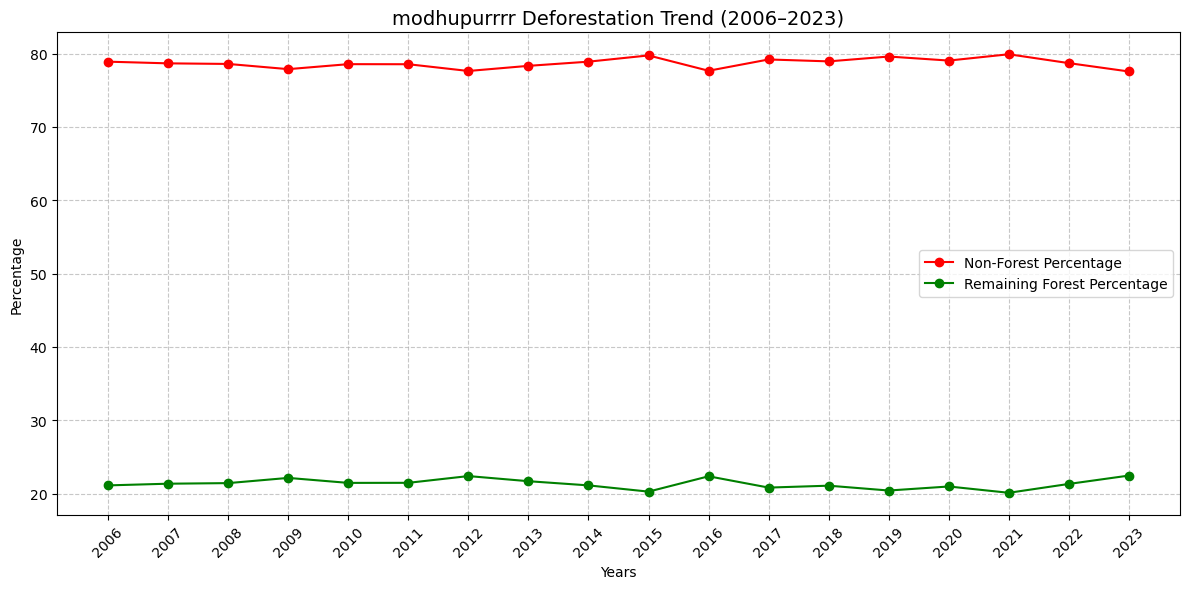

In [16]:
import matplotlib.pyplot as plt

# Years updated to match the data length
years = [
    '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
    '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023'
]

non_forest_percentages = [
    78.89, 78.66, 78.58, 77.87, 78.55, 78.54, 77.62, 78.32, 78.89,
    79.74, 77.65, 79.19, 78.93, 79.59, 79.04, 79.90, 78.69, 77.55
]

remaining_forest_percentages = [
    21.11, 21.34, 21.42, 22.13, 21.45, 21.46, 22.38, 21.68, 21.11,
    20.26, 22.35, 20.81, 21.07, 20.41, 20.96, 20.10, 21.31, 22.45
]

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(years, non_forest_percentages, marker='o', label='Non-Forest Percentage', color='red')
plt.plot(years, remaining_forest_percentages, marker='o', label='Remaining Forest Percentage', color='green')

plt.title('modhupurrrr Deforestation Trend (2006–2023)', fontsize=14)
plt.xlabel('Years')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


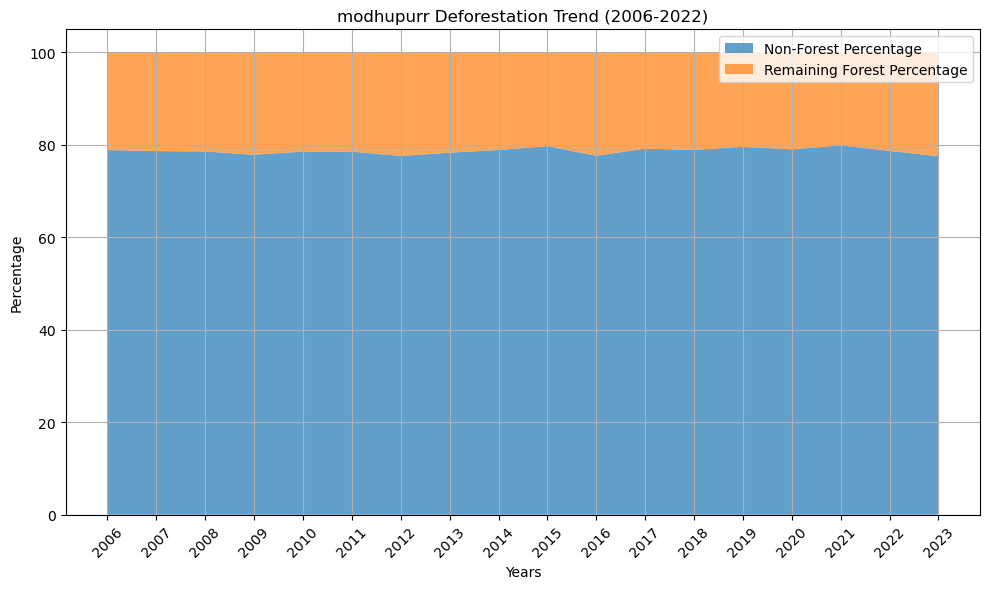

In [17]:
plt.figure(figsize=(10, 6))
plt.stackplot(years, non_forest_percentages, remaining_forest_percentages, labels=['Non-Forest Percentage', 'Remaining Forest Percentage'], alpha=0.7)

plt.title('modhupurr Deforestation Trend (2006-2022)')
plt.xlabel('Years')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


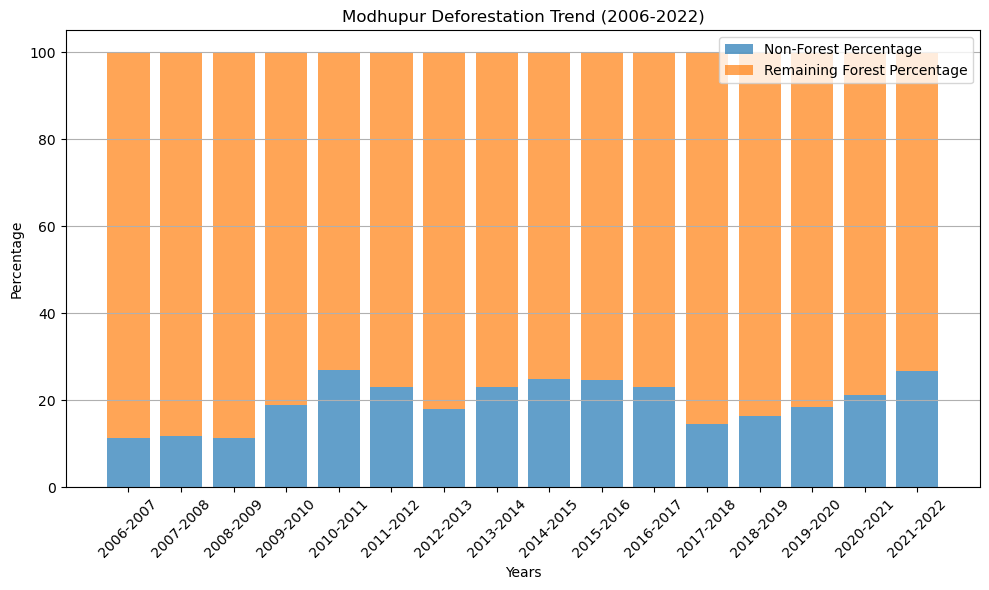

In [14]:
plt.figure(figsize=(10, 6))
plt.bar(years, non_forest_percentage, label='Non-Forest Percentage', alpha=0.7)
plt.bar(years, remaining_forest_percentage, bottom=non_forest_percentage, label='Remaining Forest Percentage', alpha=0.7)

plt.title('Modhupur Deforestation Trend (2006-2022)')
plt.xlabel('Years')
plt.ylabel('Percentage')
plt.legend()
plt.grid(axis='y')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


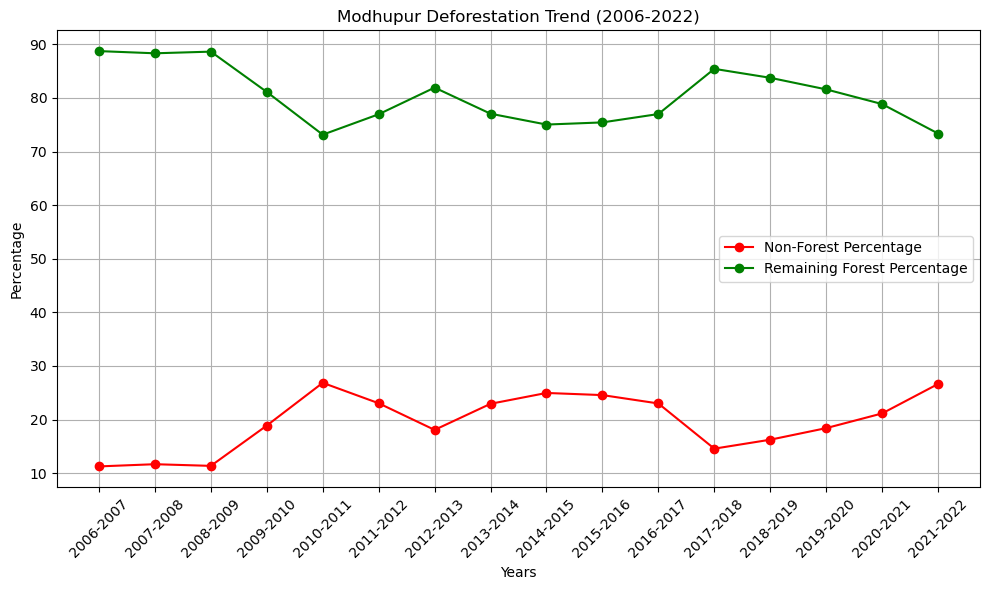

In [13]:
import matplotlib.pyplot as plt

years = ['2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022']

non_forest_percentage = [11.27, 11.68, 11.37, 18.89, 26.86, 23.05, 18.08, 22.95, 24.97, 24.57, 23.01, 14.58, 16.25, 18.41, 21.15, 26.64]
remaining_forest_percentage = [88.73, 88.32, 88.63, 81.11, 73.14, 76.95, 81.92, 77.05, 75.03, 75.43, 76.99, 85.42, 83.75, 81.59, 78.85, 73.36]

plt.figure(figsize=(10, 6))
plt.plot(years, non_forest_percentage, marker='o', label='Non-Forest Percentage', color='red')
plt.plot(years, remaining_forest_percentage, marker='o', label='Remaining Forest Percentage', color='green')

plt.title('Modhupur Deforestation Trend (2006-2022)')
plt.xlabel('Years')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


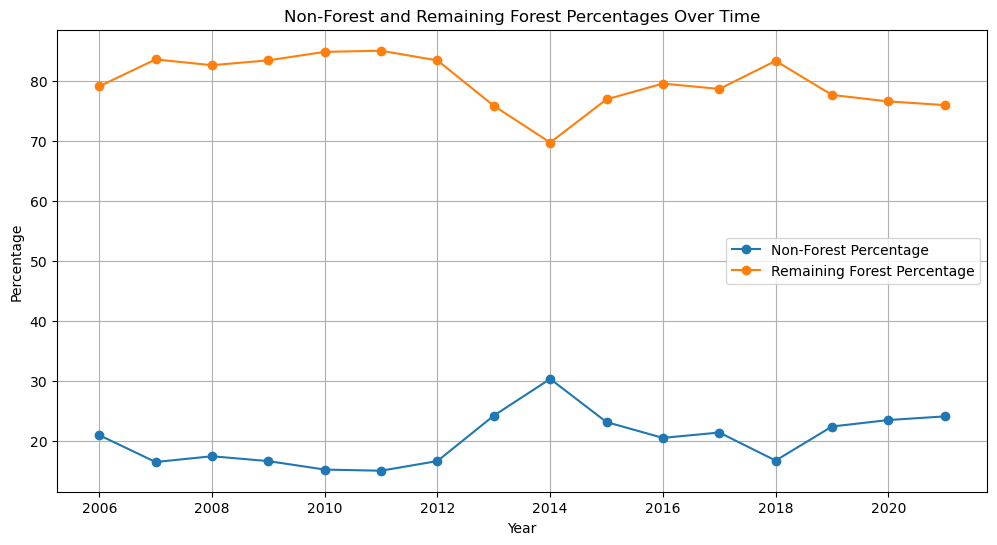

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    'Year': ['2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', 
             '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', 
             '2018-2019', '2019-2020', '2020-2021', '2021-2022'],
    'Non-Forest Percentage': [20.95, 16.48, 17.44, 16.63, 15.22, 15.03, 16.64, 24.21, 
                              30.32, 23.13, 20.50, 21.39, 16.72, 22.39, 23.47, 24.08],
    'Remaining Forest Percentage': [79.05, 83.52, 82.56, 83.37, 84.78, 84.97, 83.36, 75.79, 
                                    69.68, 76.87, 79.50, 78.61, 83.28, 77.61, 76.53, 75.92]
}

df = pd.DataFrame(data)
# Split the year range and take the first year as the datetime
df['Year'] = df['Year'].apply(lambda x: pd.to_datetime(x.split('-')[0], format='%Y'))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['Non-Forest Percentage'], label='Non-Forest Percentage', marker='o')
plt.plot(df['Year'], df['Remaining Forest Percentage'], label='Remaining Forest Percentage', marker='o')
plt.title('Non-Forest and Remaining Forest Percentages Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results wil

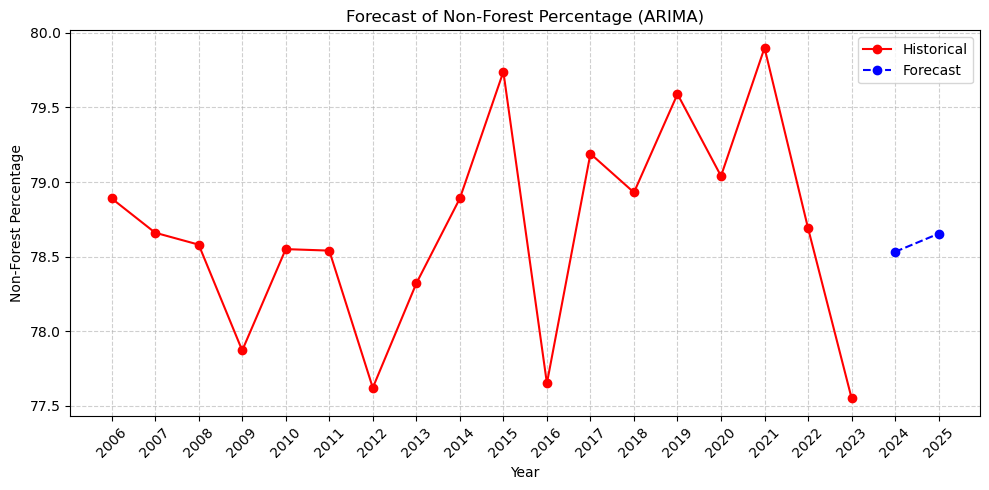

Forecasted Non-Forest Percentage for 2024: 78.53%
Forecasted Non-Forest Percentage for 2025: 78.65%


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Prepare the time series data
years = list(range(2006, 2024))
non_forest_percentages = [
    78.89, 78.66, 78.58, 77.87, 78.55, 78.54, 77.62, 78.32, 78.89,
    79.74, 77.65, 79.19, 78.93, 79.59, 79.04, 79.90, 78.69, 77.55
]

# Convert to pandas Series
data = pd.Series(non_forest_percentages, index=pd.Index(years, name="Year"))

# Fit ARIMA model (auto order tuning can be done with pmdarima, but we manually pick for now)
model = ARIMA(data, order=(1, 1, 1))  # (p, d, q)
model_fit = model.fit()

# Forecast for next 2 years (2024 & 2025)
forecast = model_fit.forecast(steps=2)
forecast_years = [2024, 2025]

# Combine with original data for plotting
all_years = years + forecast_years
all_values = non_forest_percentages + list(forecast)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, non_forest_percentages, label="Historical", marker='o', color='red')
plt.plot(forecast_years, forecast, label="Forecast", marker='o', linestyle='--', color='blue')
plt.title("Forecast of Non-Forest Percentage (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Non-Forest Percentage")
plt.xticks(all_years, rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Print forecast values
for year, value in zip(forecast_years, forecast):
    print(f"Forecasted Non-Forest Percentage for {year}: {value:.2f}%")


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results wil

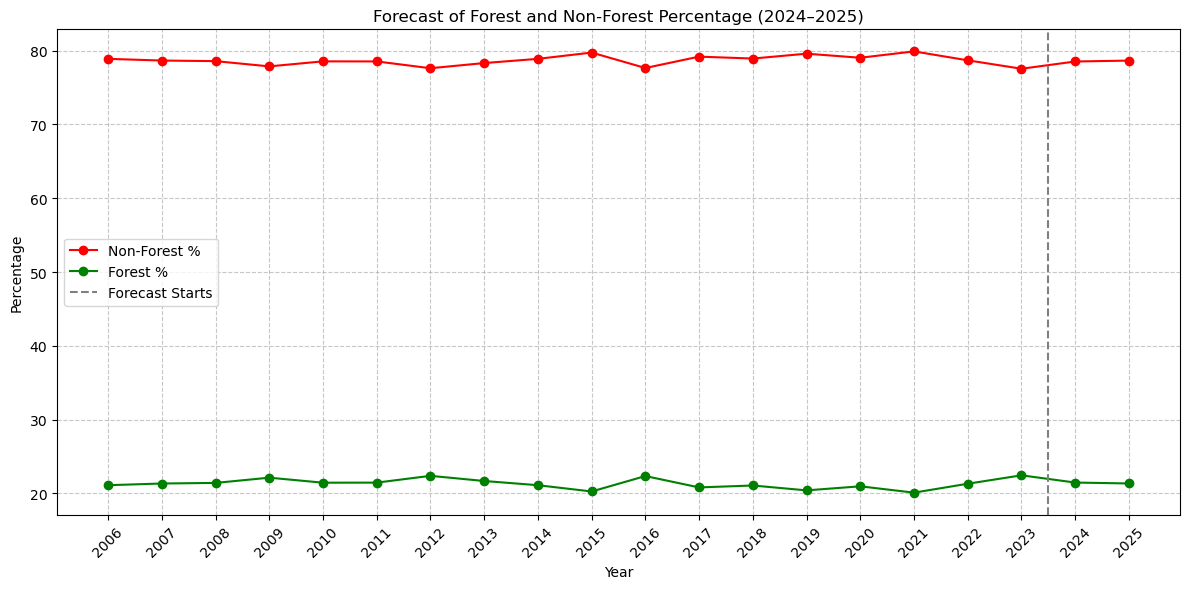

Year 2024 - Forecasted:
  Non-Forest Percentage: 78.53%
  Forest Percentage: 21.47%
Year 2025 - Forecasted:
  Non-Forest Percentage: 78.65%
  Forest Percentage: 21.35%


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Historical data
years = list(range(2006, 2024))
non_forest_percentages = [
    78.89, 78.66, 78.58, 77.87, 78.55, 78.54, 77.62, 78.32, 78.89,
    79.74, 77.65, 79.19, 78.93, 79.59, 79.04, 79.90, 78.69, 77.55
]

# Convert to time series
data = pd.Series(non_forest_percentages, index=pd.Index(years, name="Year"))

# Fit ARIMA model
model = ARIMA(data, order=(1, 1, 1))  # You can tune this
model_fit = model.fit()

# Forecast for 2024 and 2025
forecast_steps = 2
forecast_years = [2024, 2025]
forecast_non_forest = model_fit.forecast(steps=forecast_steps)
forecast_forest = 100 - forecast_non_forest

# Combine full time series
all_years = years + forecast_years
all_non_forest = non_forest_percentages + list(forecast_non_forest)
all_forest = [100 - val for val in all_non_forest]

# Plot both
plt.figure(figsize=(12, 6))
plt.plot(all_years, all_non_forest, marker='o', label="Non-Forest %", color='red')
plt.plot(all_years, all_forest, marker='o', label="Forest %", color='green')
plt.axvline(x=2023.5, color='gray', linestyle='--', label='Forecast Starts')
plt.title("Forecast of Forest and Non-Forest Percentage (2024–2025)")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(all_years, rotation=45)
plt.tight_layout()
plt.show()

# Print forecasted values


for i in range(forecast_steps):
    print(f"Year {forecast_years[i]} - Forecasted:")
    print(f"  Non-Forest Percentage: {forecast_non_forest.iloc[i]:.2f}%")
    print(f"  Forest Percentage: {forecast_forest.iloc[i]:.2f}%")


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Firoz\AppData\Local\Temp\ipykernel_23464\3082867418.py:31: FutureWarning: The frame.append method is deprecated and will be removed from pa

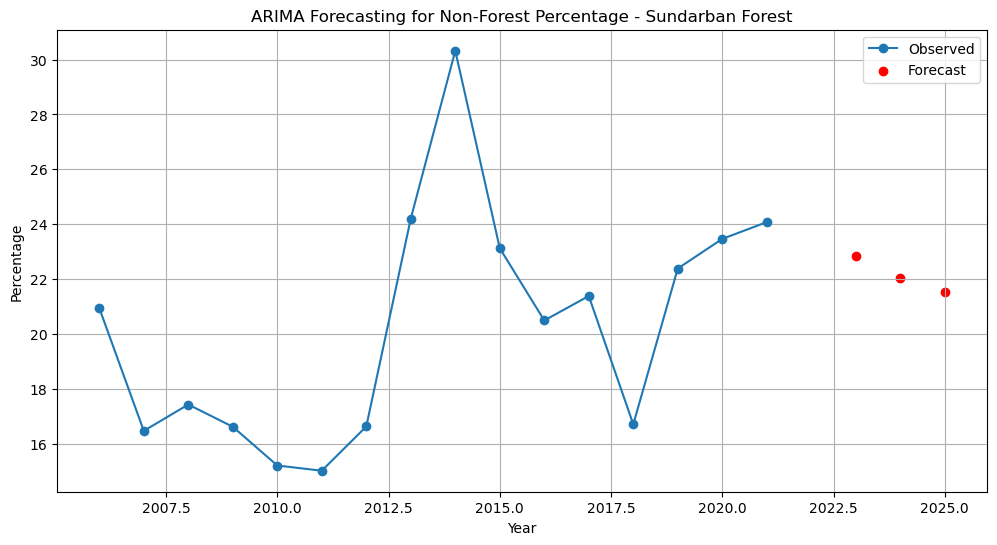

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load the data
data = {
    'Year': ['2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012',
             '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018',
             '2018-2019', '2019-2020', '2020-2021', '2021-2022'],
    'Non-Forest Percentage': [20.95, 16.48, 17.44, 16.63, 15.22, 15.03, 16.64, 24.21,
                              30.32, 23.13, 20.50, 21.39, 16.72, 22.39, 23.47, 24.08],
    'Remaining Forest Percentage': [79.05, 83.52, 82.56, 83.37, 84.78, 84.97, 83.36, 75.79,
                                    69.68, 76.87, 79.50, 78.61, 83.28, 77.61, 76.53, 75.92]
}

df = pd.DataFrame(data)
df['Year'] = df['Year'].apply(lambda x: int(x.split('-')[0]))
df.set_index('Year', inplace=True)

# Model fitting
model = ARIMA(df['Non-Forest Percentage'], order=(1, 1, 1))  # Example order, you may need to adjust
results = model.fit()

# Forecasting for the years 2023 and 2024
future_years = [2023, 2024, 2025]
forecast_values = results.get_forecast(steps=len(future_years)).predicted_mean

# Extend the time index for the forecasted years
df_forecast = df.copy()
df_forecast = df_forecast.append(pd.DataFrame(index=future_years))  # Extend the time index for the forecasted years
df_forecast.loc[future_years, 'Non-Forest Percentage'] = forecast_values

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_forecast.index, df_forecast['Non-Forest Percentage'], label='Observed', marker='o')
plt.scatter(future_years, forecast_values, color='red', label='Forecast', marker='o')
plt.title('ARIMA Forecasting for Non-Forest Percentage - Sundarban Forest')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True)
plt.show()


ADF Statistic: -1.7851179954018699
p-value: 0.387874824106442
Critical Values: {'1%': -4.137829282407408, '5%': -3.1549724074074077, '10%': -2.7144769444444443}
Taking difference to achieve stationarity.


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Firoz\AppData\Local\Temp\ipykernel_23464\4175800141.py:45: FutureWarning: The frame.append method is deprecated and will be removed from pa

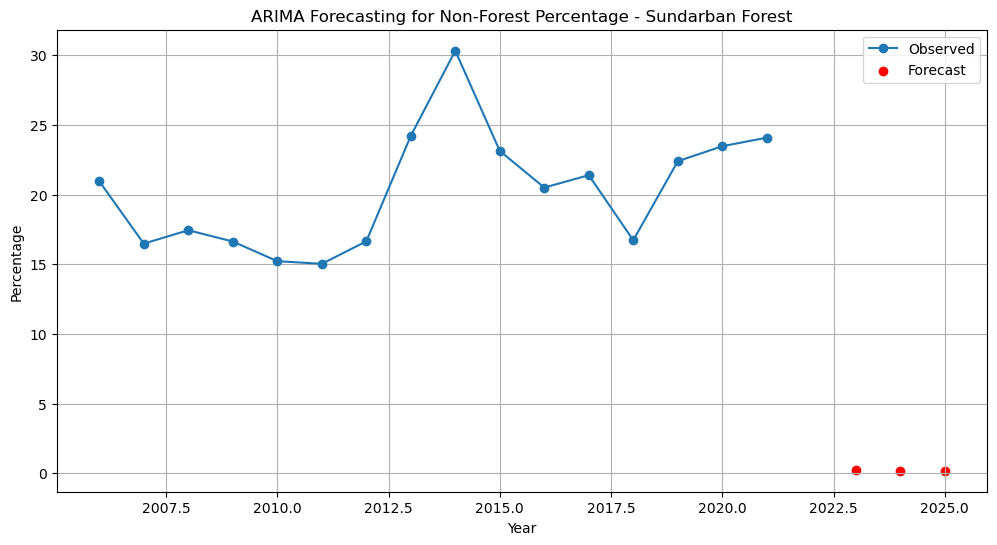

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Load the data
data = {
    'Year': ['2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012',
             '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018',
             '2018-2019', '2019-2020', '2020-2021', '2021-2022'],
    'Non-Forest Percentage': [20.95, 16.48, 17.44, 16.63, 15.22, 15.03, 16.64, 24.21,
                              30.32, 23.13, 20.50, 21.39, 16.72, 22.39, 23.47, 24.08],
    'Remaining Forest Percentage': [79.05, 83.52, 82.56, 83.37, 84.78, 84.97, 83.36, 75.79,
                                    69.68, 76.87, 79.50, 78.61, 83.28, 77.61, 76.53, 75.92]
}

df = pd.DataFrame(data)
df['Year'] = df['Year'].apply(lambda x: int(x.split('-')[0]))
df.set_index('Year', inplace=True)

# Stationarity testing using Augmented Dickey-Fuller test
result = adfuller(df['Non-Forest Percentage'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# If the data is not stationary, take the difference
if result[1] > 0.05:
    df_diff = df.diff().dropna()
    print('Taking difference to achieve stationarity.')
else:
    df_diff = df.copy()

# Model fitting
model = ARIMA(df_diff['Non-Forest Percentage'], order=(1, 1, 1))  # Example order, you may need to adjust
results = model.fit()

# Forecasting for the years 2023 and 2024
future_years = [2023, 2024, 2025]
forecast_values = results.get_forecast(steps=len(future_years)).predicted_mean

# Extend the time index for the forecasted years
df_forecast = df.copy()
df_forecast = df_forecast.append(pd.DataFrame(index=future_years))  # Extend the time index for the forecasted years
df_forecast.loc[future_years, 'Non-Forest Percentage'] = forecast_values

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_forecast.index, df_forecast['Non-Forest Percentage'], label='Observed', marker='o')
plt.scatter(future_years, forecast_values, color='red', label='Forecast', marker='o')
plt.title('ARIMA Forecasting for Non-Forest Percentage - Sundarban Forest')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Load the data
data = {
    'Year': ['2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012',
             '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018',
             '2018-2019', '2019-2020', '2020-2021', '2021-2022'],
    'Non-Forest Percentage': [20.95, 16.48, 17.44, 16.63, 15.22, 15.03, 16.64, 24.21,
                              30.32, 23.13, 20.50, 21.39, 16.72, 22.39, 23.47, 24.08],
    'Remaining Forest Percentage': [79.05, 83.52, 82.56, 83.37, 84.78, 84.97, 83.36, 75.79,
                                    69.68, 76.87, 79.50, 78.61, 83.28, 77.61, 76.53, 75.92]
}

df = pd.DataFrame(data)
df['Year'] = df['Year'].apply(lambda x: int(x.split('-')[0]))
df.set_index('Year', inplace=True)

# Stationarity testing using Augmented Dickey-Fuller test
result = adfuller(df['Non-Forest Percentage'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# If the data is not stationary, take the difference
if result[1] > 0.05:
    df_diff = df.diff().dropna()
    print('Taking difference to achieve stationarity.')
else:
    df_diff = df.copy()

# Model fitting
model = ARIMA(df_diff['Non-Forest Percentage'], order=(1, 1, 1))  # Example order, you may need to adjust
results = model.fit()

# Forecasting for the years 2023 and 2024
future_years = [2023, 2024, 2025]
forecast_values = results.get_forecast(steps=len(future_years)).predicted_mean

# Extend the time index for the forecasted years
df_forecast = df.copy()
df_forecast = df_forecast.append(pd.DataFrame(index=future_years))  # Extend the time index for the forecasted years
df_forecast.loc[future_years, 'Non-Forest Percentage'] = forecast_values

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_forecast.index, df_forecast['Non-Forest Percentage'], label='Observed', marker='o')
plt.scatter(future_years, forecast_values, color='red', label='Forecast', marker='o')
plt.title('ARIMA Forecasting for Non-Forest Percentage - Sundarban Forest')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Load the data
data = {
    'Year': ['2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012',
             '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018',
             '2018-2019', '2019-2020', '2020-2021', '2021-2022'],
    'Non-Forest Percentage': [20.95, 16.48, 17.44, 16.63, 15.22, 15.03, 16.64, 24.21,
                              30.32, 23.13, 20.50, 21.39, 16.72, 22.39, 23.47, 24.08],
    'Remaining Forest Percentage': [79.05, 83.52, 82.56, 83.37, 84.78, 84.97, 83.36, 75.79,
                                    69.68, 76.87, 79.50, 78.61, 83.28, 77.61, 76.53, 75.92]
}

df = pd.DataFrame(data)
df['Year'] = df['Year'].apply(lambda x: int(x.split('-')[0]))
df.set_index('Year', inplace=True)

# Stationarity testing using Augmented Dickey-Fuller test
result = adfuller(df['Non-Forest Percentage'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# If the data is not stationary, take the difference
if result[1] > 0.05:
    df_diff = df.diff().dropna()
    print('Taking difference to achieve stationarity.')
else:
    df_diff = df.copy()

# Model fitting
model = ARIMA(df['Non-Forest Percentage'], order=(1, 1, 1))  # Example order, you may need to adjust
results = model.fit()

# Forecasting for the years 2023, 2024, and 2025
future_years = [2023, 2024, 2025]
forecast_values = results.get_forecast(steps=len(future_years)).predicted_mean

# Extend the time index for the forecasted years
df_forecast = df.copy()
df_forecast = df_forecast.append(pd.DataFrame(index=future_years))  # Extend the time index for the forecasted years
df_forecast.loc[future_years, 'Non-Forest Percentage'] = forecast_values

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_forecast.index, df_forecast['Non-Forest Percentage'], label='Observed', marker='o')
plt.scatter(future_years, forecast_values, color='red', label='Forecast', marker='o')
plt.title('ARIMA Forecasting for Non-Forest Percentage - Sundarban Forest')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Load the data
data = {
    'Year': ['2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012',
             '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018',
             '2018-2019', '2019-2020', '2020-2021', '2021-2022'],
    'Non-Forest Percentage': [20.95, 16.48, 17.44, 16.63, 15.22, 15.03, 16.64, 24.21,
                              30.32, 23.13, 20.50, 21.39, 16.72, 22.39, 23.47, 24.08],
    'Remaining Forest Percentage': [79.05, 83.52, 82.56, 83.37, 84.78, 84.97, 83.36, 75.79,
                                    69.68, 76.87, 79.50, 78.61, 83.28, 77.61, 76.53, 75.92]
}

df = pd.DataFrame(data)
df['Year'] = df['Year'].apply(lambda x: int(x.split('-')[0]))
df.set_index('Year', inplace=True)

# Stationarity testing using Augmented Dickey-Fuller test
result = adfuller(df['Non-Forest Percentage'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# If the data is not stationary, take the difference
if result[1] > 0.05:
    df_diff = df.diff().dropna()
    print('Taking difference to achieve stationarity.')
else:
    df_diff = df.copy()

# Model fitting
model = ARIMA(df['Non-Forest Percentage'], order=(1, 1, 1))  # Example order, you may need to adjust
results = model.fit()

# Forecasting for the years 2023, 2024, and 2025
future_years = [2022, 2023, 2024, 2025]
forecast_values = results.get_forecast(steps=len(future_years)).predicted_mean

# Extend the time index for the forecasted years
df_forecast = df.copy()
df_forecast = df_forecast.append(pd.DataFrame(index=future_years))  # Extend the time index for the forecasted years
df_forecast.loc[future_years, 'Non-Forest Percentage'] = forecast_values

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_forecast.index, df_forecast['Non-Forest Percentage'], label='Observed', marker='o')
plt.scatter(future_years, forecast_values, color='red', label='Forecast', marker='o')
plt.title('ARIMA Forecasting for Non-Forest Percentage - Sundarban Forest')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(df_forecast.index)  # Set x-axis ticks to match the index
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Load the data
data = {
    'Year': ['2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012',
             '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018',
             '2018-2019', '2019-2020', '2020-2021', '2021-2022'],
    'Non-Forest Percentage': [20.95, 16.48, 17.44, 16.63, 15.22, 15.03, 16.64, 24.21,
                              30.32, 23.13, 20.50, 21.39, 16.72, 22.39, 23.47, 24.08],
    'Remaining Forest Percentage': [79.05, 83.52, 82.56, 83.37, 84.78, 84.97, 83.36, 75.79,
                                    69.68, 76.87, 79.50, 78.61, 83.28, 77.61, 76.53, 75.92]
}

df = pd.DataFrame(data)
df['Year'] = df['Year'].apply(lambda x: int(x.split('-')[0]))
df.set_index('Year', inplace=True)

# Stationarity testing using Augmented Dickey-Fuller test
result = adfuller(df['Remaining Forest Percentage'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# If the data is not stationary, take the difference
if result[1] > 0.05:
    df_diff = df.diff().dropna()
    print('Taking difference to achieve stationarity.')
else:
    df_diff = df.copy()

# Model fitting
model = ARIMA(df['Remaining Forest Percentage'], order=(1, 1, 1))  # Example order, you may need to adjust
results = model.fit()

# Forecasting for the years 2022, 2023, 2024, and 2025
future_years = [2022, 2023, 2024, 2025]
forecast_values = results.get_forecast(steps=len(future_years)).predicted_mean

# Extend the time index for the forecasted years
df_forecast = df.copy()
df_forecast = df_forecast.append(pd.DataFrame(index=future_years))  # Extend the time index for the forecasted years
df_forecast.loc[future_years, 'Remaining Forest Percentage'] = forecast_values

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_forecast.index, df_forecast['Remaining Forest Percentage'], label='Observed', marker='o')
plt.scatter(future_years, forecast_values, color='red', label='Forecast', marker='o')
plt.title('ARIMA Forecasting for Remaining Forest Percentage - Sundarban Forest')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(df_forecast.index)  # Set x-axis ticks to match the index
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Load the data
# Load the data
data = {
    'Year': ['2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012',
             '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018',
             '2018-2019', '2019-2020', '2020-2021', '2021-2022'],
    'Non-Forest Percentage': [11.27, 11.68, 11.37, 18.89, 26.86, 23.05, 18.08, 22.95, 24.97,
                              24.57, 23.01, 14.58, 16.25, 18.41, 21.15, 26.64],
    'Remaining Forest Percentage': [88.73, 88.32, 88.63, 81.11, 73.14, 76.95, 81.92, 77.05, 75.03,
                                    75.43, 76.99, 85.42, 83.75, 81.59, 78.85, 73.36]
}

df = pd.DataFrame(data)
df['Year'] = df['Year'].apply(lambda x: int(x.split('-')[0]))
df.set_index('Year', inplace=True)

# Stationarity testing using Augmented Dickey-Fuller test
result = adfuller(df['Remaining Forest Percentage'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# If the data is not stationary, take the difference
if result[1] > 0.05:
    df_diff = df.diff().dropna()
    print('Taking difference to achieve stationarity.')
else:
    df_diff = df.copy()

# Model fitting
model = ARIMA(df['Remaining Forest Percentage'], order=(1, 1, 1))  # Example order, you may need to adjust
results = model.fit()

# Forecasting for the years 2022, 2023, 2024, and 2025
future_years = [2022, 2023, 2024, 2025]
forecast_values = results.get_forecast(steps=len(future_years)).predicted_mean

# Extend the time index for the forecasted years
df_forecast = df.copy()
df_forecast = df_forecast.append(pd.DataFrame(index=future_years))  # Extend the time index for the forecasted years
df_forecast.loc[future_years, 'Remaining Forest Percentage'] = forecast_values

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_forecast.index, df_forecast['Remaining Forest Percentage'], label='Observed', marker='o')
plt.scatter(future_years, forecast_values, color='red', label='Forecast', marker='o')
plt.title('ARIMA Forecasting for Remaining Forest Percentage - Modhupur Forest')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(df_forecast.index)  # Set x-axis ticks to match the index
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Load the data
data = {
    'Year': ['2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012',
             '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018',
             '2018-2019', '2019-2020', '2020-2021', '2021-2022'],
    'Non-Forest Percentage': [11.27, 11.68, 11.37, 18.89, 26.86, 23.05, 18.08, 22.95, 24.97,
                              24.57, 23.01, 14.58, 16.25, 18.41, 21.15, 26.64],
    'Remaining Forest Percentage': [88.73, 88.32, 88.63, 81.11, 73.14, 76.95, 81.92, 77.05, 75.03,
                                    75.43, 76.99, 85.42, 83.75, 81.59, 78.85, 73.36]
}

df = pd.DataFrame(data)
df['Year'] = df['Year'].apply(lambda x: int(x.split('-')[0]))
df.set_index('Year', inplace=True)

# Stationarity testing using Augmented Dickey-Fuller test
result = adfuller(df['Non-Forest Percentage'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# If the data is not stationary, take the difference
if result[1] > 0.05:
    df_diff = df.diff().dropna()
    print('Taking difference to achieve stationarity.')
else:
    df_diff = df.copy()

# Model fitting
model = ARIMA(df['Non-Forest Percentage'], order=(1, 1, 1))  # Example order, you may need to adjust
results = model.fit()

# Forecasting for the years 2023, 2024, and 2025
future_years = [2022, 2023, 2024, 2025]
forecast_values = results.get_forecast(steps=len(future_years)).predicted_mean

# Extend the time index for the forecasted years
df_forecast = df.copy()
df_forecast = df_forecast.append(pd.DataFrame(index=future_years))  # Extend the time index for the forecasted years
df_forecast.loc[future_years, 'Non-Forest Percentage'] = forecast_values

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_forecast.index, df_forecast['Non-Forest Percentage'], label='Observed', marker='o')
plt.scatter(future_years, forecast_values, color='red', label='Forecast', marker='o')
plt.title('ARIMA Forecasting for Non-Forest Percentage - Modhupur Forest')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(df_forecast.index)  # Set x-axis ticks to match the index
plt.legend()
plt.grid(True)
plt.show()
